In [3]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
df = pd.read_csv(
    "/content/IMDB Dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
df.shape

(8683, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8683 entries, 0 to 8682
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     8683 non-null   object
 1   sentiment  8683 non-null   object
dtypes: object(2)
memory usage: 135.8+ KB


In [10]:
df['sentiment'].value_counts()

,count
sentiment,
positive,4359
negative,4324


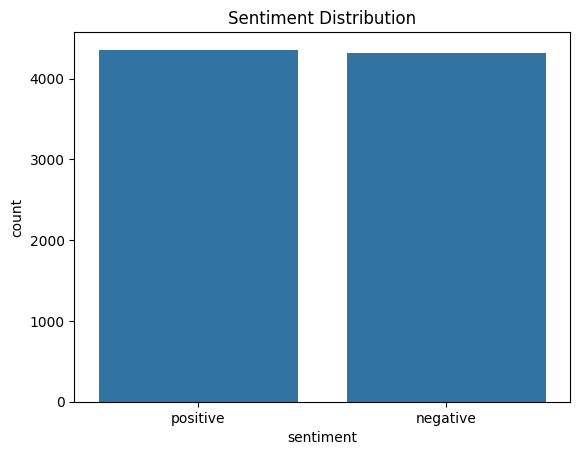

In [11]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [12]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [13]:
df['review'] = df['review'].str.lower()

In [14]:
def remove_html(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

df['review'] = df['review'].apply(remove_html)

In [15]:
def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

df['review'] = df['review'].apply(remove_urls)

In [16]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['review'] = df['review'].apply(remove_punctuation)

In [17]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

df['review'] = df['review'].apply(remove_stopwords)

In [18]:
stemmer = PorterStemmer()

def stemming(text):
    words = text.split()
    stemmed = [stemmer.stem(word) for word in words]
    return " ".join(stemmed)

df['review'] = df['review'].apply(stemming)

In [19]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [20]:
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [21]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [22]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [23]:
lr = LogisticRegression()

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8814047207829592
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       877
           1       0.87      0.89      0.88       860

    accuracy                           0.88      1737
   macro avg       0.88      0.88      0.88      1737
weighted avg       0.88      0.88      0.88      1737



In [25]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.8635578583765112
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       877
           1       0.86      0.87      0.86       860

    accuracy                           0.86      1737
   macro avg       0.86      0.86      0.86      1737
weighted avg       0.86      0.86      0.86      1737



In [27]:
dt = DecisionTreeClassifier()

dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6948762233736328
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       877
           1       0.70      0.68      0.69       860

    accuracy                           0.69      1737
   macro avg       0.69      0.69      0.69      1737
weighted avg       0.69      0.69      0.69      1737



In [29]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Naive Bayes','Decision Tree'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_dt)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.881405
1,Naive Bayes,0.863558
2,Decision Tree,0.694876


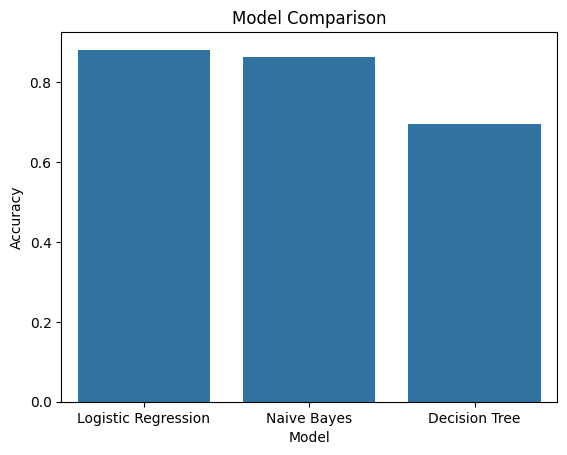

In [30]:
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Comparison")
plt.show()

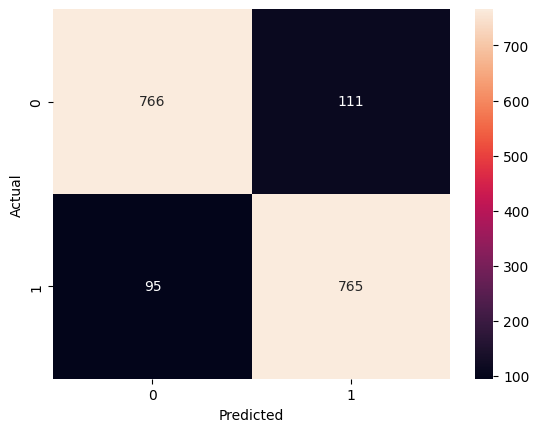

In [31]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()